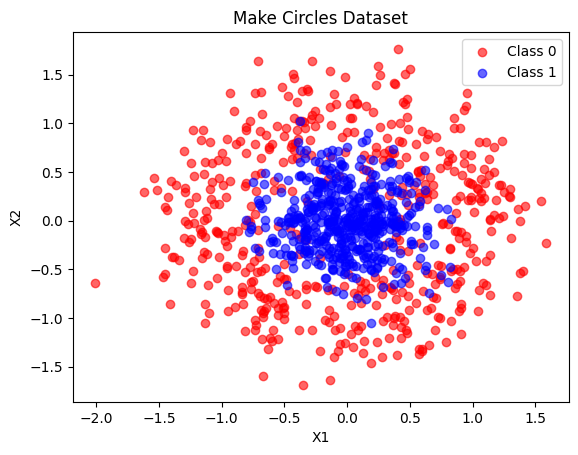

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from flashlight import Tensor, randn
from flashlight import neural
from flashlight.functions import softmax, nll_loss

X, y = make_circles(n_samples=1000, noise=0.3, factor=0.2, random_state=12)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[y==0, 0], X[y==0, 1], c='red', alpha=0.6, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', alpha=0.6, label='Class 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Make Circles Dataset')
plt.legend()
plt.show()


Epoch 0, Loss: 0.6924
Epoch 50, Loss: 0.6215
Epoch 100, Loss: 0.5755
Epoch 150, Loss: 0.5405
Epoch 200, Loss: 0.5124
Epoch 250, Loss: 0.4892
Epoch 300, Loss: 0.4695
Epoch 350, Loss: 0.4526
Epoch 400, Loss: 0.4378
Epoch 450, Loss: 0.4249


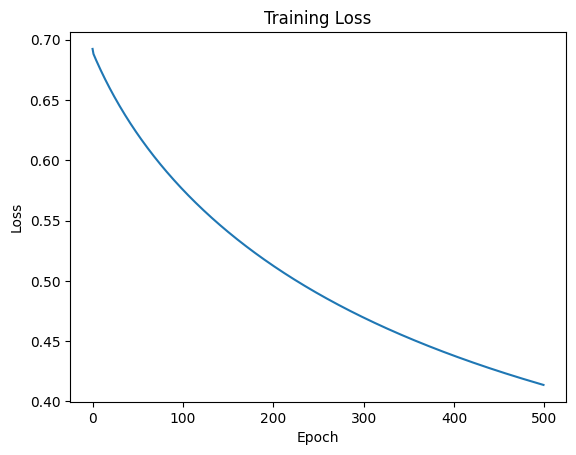

In [8]:
def calculate_output(x):
    return x

def calculate_loss(output, target):
    probs = softmax(output, dim=-1)
    return nll_loss(probs, target)

net = neural.NeuralNet(
    calculate_output=calculate_output,
    calculate_loss=calculate_loss
)

net.add_layer(neural.Linear(2, 64))
net.add_layer(neural.Relu())
net.add_layer(neural.Linear(64, 32))
net.add_layer(neural.Relu())
net.add_layer(neural.Linear(32, 2))

X_tensor = Tensor(X_train.astype(np.float32))
y_tensor = Tensor(y_train.astype(np.int64))

losses = []
for epoch in range(500):
    loss = net.train(X_tensor, y_tensor, lr=0.1)
    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


Test Accuracy: 0.8650


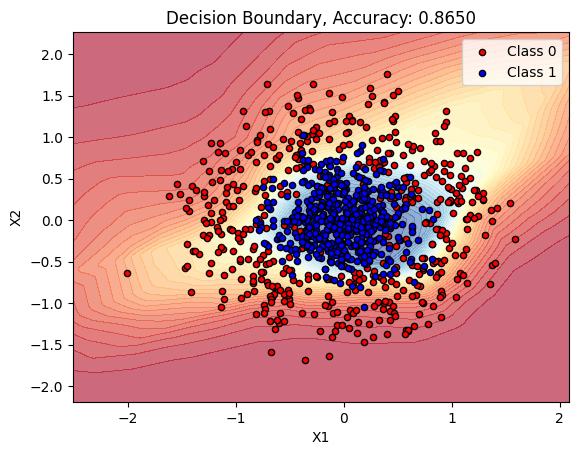

In [12]:
net.set_training(False)

X_test_tensor = Tensor(X_test.astype(np.float32))
y_test_tensor = Tensor(y_test.astype(np.int64))

from flashlight import no_grad
with no_grad():
    test_output = net(X_test_tensor)
    test_probs = softmax(test_output, dim=-1)
    test_predictions = np.argmax(test_probs.data, axis=1)

accuracy = np.mean(test_predictions == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = Tensor(grid_points.astype(np.float32))

with no_grad():
    output = net(grid_tensor)
    probs = softmax(output, dim=-1)
    Z = probs.data[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', edgecolors='black', s=20, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolors='black', s=20, label='Class 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f"Decision Boundary, Accuracy: {accuracy:.4f}")
plt.legend()
plt.show()
